# Packed Design Considerations

How many 1-byte references do we need in Packed CBOR? This helped during the design process of Packed CBOR to set the parameters $A$, $B$, $C$ that were used in versions [-15](https://datatracker.ietf.org/doc/html/draft-ietf-cbor-packed-15) to [-18](https://datatracker.ietf.org/doc/html/draft-ietf-cbor-packed-18) of `draft-ietf-cbor-packed`. See also [Martine's slides presented at IETF 123](https://datatracker.ietf.org/meeting/123/materials/slides-123-cbor-a-concise-binary-object-representation-cbor-of-dns-messages-00).

In [1]:
import os
import pathlib
import re
import sys

import matplotlib.pyplot
import matplotlib.ticker
import numpy
import polars
import IPython.display


DNSCBOR_EVAL_DIR = pathlib.Path.cwd()
os.environ["DNSCBOR_EVAL_DIR"] = str(DNSCBOR_EVAL_DIR)

if str((DNSCBOR_EVAL_DIR / "..").absolute()) not in sys.path:
    sys.path.append(str((DNSCBOR_EVAL_DIR / "..").absolute()))

from utils import list_code

## Count Suffixes per Message in Datasets

For this, you require the `dns_data_{iot,tranco}.csv.gz` in `04_cbor4dns_eval/output_datasets/` as generated in [“Prepararations for Common IP Prefixes and Name Suffixes Analysis” notebook](./01_dataset_collection.ipynb#Extract-DNS-Data-from-PCAPs) to generate `dns_suffixes_{iot,tranco}.csv.gz`. Our dataset on [Zenodo](TBD) also includes `dns_suffixes_ditl_a-root_sfo8-a.csv.gz` which was generated from the [DNS-OARC “Day in a Live” (DITL) traces](https://www.dns-oarc.net/oarc/data/ditl) at the DNS root A server in San Francisco. Since this dataset us undisclosed, we did not provide a `dns_data_ditl_a-root_sfo8-a.csv.gz` in our dataset. This file was generated on an OARC server using the same script as for the other two, but the data remained that server.

In [2]:
list_code(DNSCBOR_EVAL_DIR / "count_suffixes.py")

#! /usr/bin/env python3
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import csv
import gzip
import sys


import cbor4dns_utils


NAME_COLS = [
    "dns.qry.name",
    "dns.resp.name",
    "dns.afsdb.hostname",
    "dns.cname",
    "dns.dname",
    "dns.mr",
    "dns.ns",
    "dns.nsec.next_domain_name",
    "dns.ptr.domain_name",
    "dns.rrsig.signers_name",
    "dns.rt.intermediate_host",
    "dns.soa.mname",
    "dns.soa.rname",
    "dns.srv.name",
    "dns.svcb.targetname",
    "dns.winsr.name_result_domain",
]


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(metavar="<Input CSV filename>", dest="csv")
    args = parser.parse_args()
    if args.csv == "-":
        open_func = lambda *args, **kwargs: sys.stdin
    elif args.csv.endswith(".gz"):
        open_func = gzip.open
    else:
        open_func = open

    # use maximum possible size for field size
    max_int = sys.maxsize
    while True:
        try:
            csv.field_size_limit(max_int)
            break
        except OverflowError:
            max_int = (max_int >> 2)

    with open_func(args.csv, "rt", encoding="utf-8") as in_csvfile:
        reader = csv.DictReader(in_csvfile, delimiter=";")
        out_csvfile = sys.stdout
        for row in reader:
            suffixes = dict()
            for col in NAME_COLS:
                if row[col]:
                    names = row[col].split("|")
                    for name in names:
                        components = name.split(".")
                        for i in range(len(components)):
                            suffix = tuple(components[i:])
                            if suffix in suffixes:
                                suffixes[suffix] += 1
                            else:
                                suffixes[suffix] = 1
            print(len(suffixes))


if __name__ == "__main__":
    main()

To start a detached TMUX session running this script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${DNSCBOR_EVAL_DIR}'/../.env/bin/activate;` before the `${DNSCBOR_EVAL_DIR}/count_suffixes.py`):

In [3]:
%%bash

tmux new-session -s "count_suffixes" -d \
    "'${DNSCBOR_EVAL_DIR}'/count_suffixes.py '${DNSCBOR_EVAL_DIR}/output_datasets/dns_data_iot.csv.gz' | \
        pigz > '${DNSCBOR_EVAL_DIR}/output_datasets/dns_suffixes_iot.csv.gz'; \
    '${DNSCBOR_EVAL_DIR}'/count_suffixes.py '${DNSCBOR_EVAL_DIR}/output_datasets/dns_data_tranco.csv.gz' | \
        pigz > '${DNSCBOR_EVAL_DIR}/output_datasets/dns_suffixes_tranco.csv.gz'"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "count_suffixes"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "count_suffixes" C-c
```

## Load Dataframes

In [4]:
dfs = [
    polars.read_csv(
        DNSCBOR_EVAL_DIR / "output_datasets" / f"dns_suffixes_{dataset}.csv.gz",
        has_header=False,
        new_columns=[dataset_name],
    )
    for dataset, dataset_name in [
        ("iot", "IoT Testbeds"),
        ("tranco", "Public Resolver"),
        ("ditl_a-root_sfo8-a", "Root-A"),
    ]
]

## Violin Plot Number of Suffixes per Message per Dataset

This may run for a while due to the size of the DITL dataset...

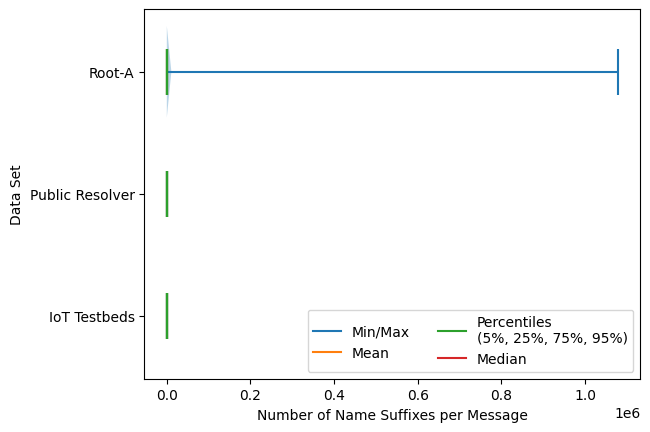

In [5]:
violin = matplotlib.pyplot.violinplot(
    [
        df[df.columns[0]] for df in dfs
    ],
    [i for i in range(len(dfs))],
    showmeans=True,
    showmedians=True,
    widths=0.75,
    quantiles=[[.5, .25, .75, .95] for _ in dfs],
    vert=False,
)
violin["cmeans"].set_edgecolor("C1")
violin["cquantiles"].set_edgecolor("C2")
violin["cmedians"].set_edgecolor("C3")
matplotlib.pyplot.xlabel("Number of Name Suffixes per Message")
matplotlib.pyplot.yticks([i for i in range(len(dfs))], [df.columns[0] for df in dfs])
matplotlib.pyplot.ylabel("Data Set")
legend_lines = [
    matplotlib.lines.Line2D([0], [0], color="C0"),
    matplotlib.lines.Line2D([0], [0], color="C1"),
    matplotlib.lines.Line2D([0], [0], color="C2"),
    matplotlib.lines.Line2D([0], [0], color="C3"),
]
matplotlib.pyplot.legend(
    legend_lines,
    ["Min/Max", "Mean", "Percentiles\n(5%, 25%, 75%, 95%)", "Median"],
    ncol=2,
    loc="lower right",
)
matplotlib.pyplot.show()

In [6]:
stats = polars.DataFrame(
    [
        {
            "Dataset": d.columns[0],
            "#": int(d.count()[0, 0]),
            "μ": d.mean()[0, 0],
            "σ": d.std()[0, 0],
            "mode": d.with_columns(
                polars.col(d.columns[0]).mode().first().alias("mode")
            )["mode"][0],
            "min": d.min()[0, 0],
            "max": d.max()[0, 0],
            "5%": d.quantile(.5)[0, 0],
            "25%": d.quantile(.25)[0, 0],
            "50%": d.median()[0, 0],
            "75%": d.quantile(.75)[0, 0],
            "95%": d.quantile(.95)[0, 0],
        }
        for d in dfs
    ]
).select(
    polars.col("Dataset"),
    polars.col("#").cast(polars.UInt32),
    polars.col("μ"),
    polars.col("σ"),
    polars.col("mode").cast(polars.UInt8),
    polars.col("min").cast(polars.UInt8),
    polars.col("max").cast(polars.UInt32),
    polars.col("5%").cast(polars.UInt8),
    polars.col("25%").cast(polars.UInt8),
    polars.col("50%").cast(polars.UInt8),
    polars.col("75%").cast(polars.UInt8),
    polars.col("95%").cast(polars.UInt8),
)

with polars.Config(float_precision=1):
    IPython.display.display(stats)

Dataset,#,μ,σ,mode,min,max,5%,25%,50%,75%,95%
str,u32,f64,f64,u8,u8,u32,u8,u8,u8,u8,u8
"""IoT Testbeds""",3941875,4.9,3.3,3,1,39,3,3,3,6,12
"""Public Resolver""",518433377,2.4,1.2,2,1,303,2,2,2,2,6
"""Root-A""",396589550,4.5,183.9,3,0,1078112,3,3,3,5,7


## Using Parameters $A$, $B$, and $C$

To simplify plotting, this section uses the [seaborn](https://pypi.org/project/seaborn/0.13.2/) package for violin plots. It is not pre-installed in the Docker setup, so install it with the following command from your host.

```sh
cd '<This repository>'
docker-compose exec jupyter uv pip install --system "seaborn==0.13.2"
```

The files matching `dns_cbor_packed-a*encoding*` and `dns_cbor_packed-a*metric*` required for the following cells where generated with the `encode_dns+cbor.sh` as described in the [“Encode to application/dns+cbor” notebook](./02_encoding.ipynb#Encode-according-draft-lenders-dns-cbor-06) and the `compute_encoding_metrics.sh` script as described in [the same notebook](./02_encoding.ipynb#Compute-metrics). For `encode_dns+cbor.sh` the parameters `-A`, `-B`, and `-C` were used to tweak the paramerters encoded in the filename, see [script documentation](02_encoding.ipynb#The-Encoding-Script).

In [7]:
import seaborn

In [8]:
res = None

for filepath in (DNSCBOR_EVAL_DIR / "output_datasets").glob("dns_cbor_packed-a*metric*.csv.gz"):
    match = re.search(r"dns_cbor_packed-a(?P<A>\d+)-b(?P<B>\d+)-c(?P<C>\d+)_metric_iot.csv.gz", filepath.name)
    assert match
    lf = polars.scan_csv(filepath).filter(
        polars.col("msg") == "r"
    ).with_columns(
        A=polars.lit(match["A"], polars.UInt8),
        B=polars.lit(match["B"], polars.UInt8),
        C=polars.lit(match["C"], polars.UInt8),
    ).select(
        [
            "dataset",
            "pcap",
            "frame",
            "protocol",
            "qtype",
            "w_query",
            "A",
            "B",
            "C",
            "application/dns-message vs application/cbor+dns byte savings",
            "application/dns-message vs application/cbor+dns;packed=1 byte savings",
            "application/dns-message vs application/cbor+dns gain",
            "application/dns-message vs application/cbor+dns;packed=1 gain",
        ]
    )
    if res is None:
        res = lf
    else:
        new = polars.concat([res, lf])
        res = new
res.sort(["A", "B", "C"]).sink_parquet(
    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_packed_params_metric.parquet",
    compression="zstd",
    compression_level=22,
)
IPython.display.display(res.collect())

dataset,pcap,frame,protocol,qtype,w_query,A,B,C,application/dns-message vs application/cbor+dns byte savings,application/dns-message vs application/cbor+dns;packed=1 byte savings,application/dns-message vs application/cbor+dns gain,application/dns-message vs application/cbor+dns;packed=1 gain
str,str,i64,str,str,bool,u8,u8,u8,i64,i64,f64,f64
"""yourthings""","""yourthings/10/eth1-20180410.16…",128751,"""dns""","""A""",true,0,0,8,43,48,0.209756,0.234146
"""yourthings""","""yourthings/10/eth1-20180410.16…",131728,"""dns""","""A""",true,0,0,8,101,78,0.594118,0.458824
"""yourthings""","""yourthings/10/eth1-20180410.00…",132404,"""dns""","""A""",true,0,0,8,55,53,0.204461,0.197026
"""yourthings""","""yourthings/10/eth1-20180410.08…",119757,"""dns""","""A""",true,0,0,8,61,53,0.388535,0.33758
"""yourthings""","""yourthings/10/eth1-20180410.08…",120863,"""dns""","""A""",true,0,0,8,69,61,0.5390625,0.4765625
…,…,…,…,…,…,…,…,…,…,…,…,…
"""moniotr""","""moniotr/iot-data/us/wink-hub2/…",72,"""dns""","""AAAA""",true,16,32,8,50,48,0.299401,0.287425
"""moniotr""","""moniotr/iot-data/us/wink-hub2/…",98,"""dns""","""A""",true,16,32,8,55,55,0.572917,0.572917
"""moniotr""","""moniotr/iot-data/us-vpn/wansvi…",857,"""dns""","""A""",true,16,32,8,127,158,0.311275,0.387255


In [9]:
res = None

for filepath in (DNSCBOR_EVAL_DIR / "output_datasets").glob("dns_cbor_packed*encoding_iot.csv.gz"):
    match = re.search(r"dns_cbor_packed-a(?P<A>\d+)-b(?P<B>\d+)-c(?P<C>\d+).*encoding_iot.csv.gz", filepath.name)
    assert match
    lf = polars.scan_csv(filepath).filter(
        polars.col("msg") == "r"
    ).with_columns(
        A=polars.lit(match["A"], polars.UInt8),
        B=polars.lit(match["B"], polars.UInt8),
        C=polars.lit(match["C"], polars.UInt8),
    ).select(
        [
            "dataset",
            "pcap",
            "frame",
            "protocol",
            "qtype",
            "w_query",
            "A",
            "B",
            "C",
            "application/dns-message len",
            "application/cbor+dns len",
            "application/cbor+dns;packed=1 len"
        ]
    )
    if res is None:
        res = lf
    else:
        new = polars.concat([res, lf])
        res = new
res.sort(["A", "B", "C"]).sink_parquet(
    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_packed_params_encoding.parquet",
    compression="zstd",
    compression_level=22,
)
IPython.display.display(res.collect())

dataset,pcap,frame,protocol,qtype,w_query,A,B,C,application/dns-message len,application/cbor+dns len,application/cbor+dns;packed=1 len
str,str,i64,str,str,bool,u8,u8,u8,i64,i64,i64
"""yourthings""","""yourthings/10/eth1-20180410.00…",63264,"""dns""","""AAAA""",true,0,4,8,46,5,7
"""yourthings""","""yourthings/10/eth1-20180410.00…",63358,"""dns""","""A""",true,0,4,8,174,69,79
"""yourthings""","""yourthings/10/eth1-20180410.06…",57846,"""dns""","""AAAA""",true,0,4,8,60,25,27
"""yourthings""","""yourthings/10/eth1-20180410.06…",57848,"""dns""","""A""",true,0,4,8,48,15,17
"""yourthings""","""yourthings/10/eth1-20180410.06…",58742,"""dns""","""A""",true,0,4,8,77,43,46
…,…,…,…,…,…,…,…,…,…,…,…
"""moniotr""","""moniotr/iot-data/us-vpn/wansvi…",1674,"""dns""","""A""",true,16,28,8,408,281,250
"""moniotr""","""moniotr/iot-data/us-vpn/wansvi…",522,"""dns""","""A""",true,16,28,8,408,317,255
"""moniotr""","""moniotr/iot-data/us-vpn/wansvi…",1831,"""dns""","""A""",true,16,28,8,408,281,250


In [10]:
df = polars.read_parquet(
    DNSCBOR_EVAL_DIR / "output_datasets" / "dns_cbor_packed_params_encoding.parquet"
)

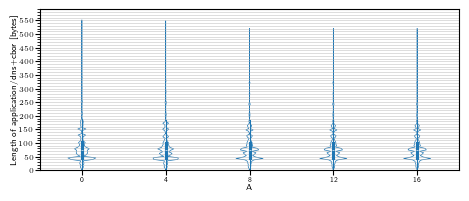

In [11]:
matplotlib.style.use("../mlenders_fullslide.mplstyle")

matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 1.5
)

boxplot = seaborn.violinplot(y="application/cbor+dns len", x="A", data=df, fill=False, width=.333)
boxplot.set_ylabel("Length of application/dns+cbor [bytes]")
boxplot.set_ylim((0, 590))
boxplot.set_yticks(numpy.arange(0, 590, 50))
boxplot.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
boxplot.grid(axis="y", which="both")
matplotlib.pyplot.savefig(
    DNSCBOR_EVAL_DIR / "plots" / "dns_cbor_params_len.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)
matplotlib.pyplot.show()

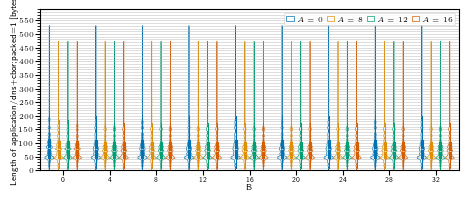

In [12]:
matplotlib.pyplot.clf()
matplotlib.style.use("../mlenders_fullslide.mplstyle")

matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0],
    matplotlib.rcParams["figure.figsize"][1] * 1.5
)

boxplot = seaborn.violinplot(
    y="application/cbor+dns;packed=1 len",
    x="B",
    hue="A",
    data=df.filter(polars.col("A").is_in([0, 8, 12, 16])),
    palette="colorblind",
    fill=False,
)
boxplot.set_ylabel("Length of application/dns+cbor;packed=1 [bytes]")
boxplot.set_ylim((0, 590))
boxplot.set_yticks(numpy.arange(0, 590, 50))
boxplot.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
boxplot.grid(axis="y", which="both")
handles, _ = boxplot.get_legend_handles_labels()
boxplot.legend(
    handles=handles,
    ncol=4,
    labels=["$A = 0$", "$A = 8$", "$A = 12$", "$A = 16$"],
)
matplotlib.pyplot.savefig(
    DNSCBOR_EVAL_DIR / "plots" / "dns_cbor_packed_C8_params_len.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)
matplotlib.pyplot.show()

In [13]:
base = ""
# base = "application/dns-message vs "
metric = "len"
# metric = "byte savings"

stats_A = df.group_by("A").agg(
    polars.col(f"{base}application/cbor+dns {metric}").min().alias("min"),
    polars.col(f"{base}application/cbor+dns {metric}").max().alias("max"),
    polars.col(f"{base}application/cbor+dns {metric}").mean().alias("mean"),
    polars.col(f"{base}application/cbor+dns {metric}").std().alias("std"),
    *[
        polars.col(f"{base}application/cbor+dns {metric}").quantile(q).alias(
            f"q_{{{q:.1f}}}" if q < 0.95 else f"q_{{{q:.2f}}}"
        )
        for q in (list(numpy.arange(0.1, 1.0, 0.1)) + [0.95])
    ]
).sort("A")

stats_packed_A_B = df.group_by(["A", "B"]).agg(
    polars.col(f"{base}application/cbor+dns;packed=1 {metric}").min().alias("min"),
    polars.col(f"{base}application/cbor+dns;packed=1 {metric}").max().alias("max"),
    polars.col(f"{base}application/cbor+dns;packed=1 {metric}").mean().alias("mean"),
    polars.col(f"{base}application/cbor+dns;packed=1 {metric}").std().alias("std"),
    *[
        polars.col(f"{base}application/cbor+dns;packed=1 {metric}").quantile(q).alias(
            f"q_{{{q:.1f}}}" if q < 0.95 else f"q_{{{q:.2f}}}"
        )
        for q in (list(numpy.arange(0.1, 1.0, 0.1)) + [0.95])
    ]
).sort(["A", "B"])

filename = f"dns_cbor_params{"_%s" % metric if metric != "byte savings" else ""}.pdf"
IPython.display.display(
    IPython.display.Markdown(
        f"### [`{filename}`]"
        f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
    )
)
IPython.display.display(stats_A)
filename = f"dns_cbor_packed_C8_params{"_%s" % metric if metric != "byte savings" else ""}.pdf"
IPython.display.display(
    IPython.display.Markdown(
        f"### [`{filename}`]"
        f"({DNSCBOR_EVAL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
    )
)
IPython.display.display(stats_packed_A_B)

### [`dns_cbor_params_len.pdf`](plots/dns_cbor_params_len.pdf)

A,min,max,mean,std,q_{0.1},q_{0.2},q_{0.3},q_{0.4},q_{0.5},q_{0.6},q_{0.7},q_{0.8},q_{0.9},q_{0.95}
u8,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,5,548,85.460144,56.377635,41.0,43.0,47.0,63.0,74.0,80.0,94.0,125.0,164.0,187.0
4,5,545,83.910175,54.685114,40.0,42.0,47.0,61.0,73.0,80.0,90.0,124.0,159.0,181.0
8,5,517,83.180841,53.401245,40.0,42.0,47.0,61.0,73.0,79.0,90.0,122.0,157.0,180.0
12,5,517,83.124326,53.320335,40.0,42.0,47.0,61.0,73.0,79.0,90.0,121.0,157.0,180.0
16,5,517,83.109123,53.290969,40.0,42.0,47.0,61.0,73.0,79.0,90.0,121.0,157.0,180.0


### [`dns_cbor_packed_C8_params_len.pdf`](plots/dns_cbor_packed_C8_params_len.pdf)

A,B,min,max,mean,std,q_{0.1},q_{0.2},q_{0.3},q_{0.4},q_{0.5},q_{0.6},q_{0.7},q_{0.8},q_{0.9},q_{0.95}
u8,u8,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,7,525,90.167128,57.37458,43.0,46.0,50.0,63.0,80.0,85.0,102.0,129.0,172.0,195.0
0,4,7,525,88.061465,56.002658,43.0,46.0,50.0,61.0,78.0,84.0,96.0,125.0,166.0,191.0
0,8,7,525,87.819266,55.301302,43.0,46.0,50.0,61.0,78.0,84.0,96.0,125.0,166.0,191.0
0,12,7,525,87.816665,55.290272,43.0,46.0,50.0,61.0,78.0,84.0,96.0,125.0,166.0,191.0
0,16,7,525,87.815818,55.286017,43.0,46.0,50.0,61.0,78.0,84.0,96.0,125.0,166.0,191.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
16,16,7,468,82.499551,49.536254,42.0,44.0,49.0,58.0,72.0,81.0,89.0,115.0,151.0,182.0
16,20,7,468,82.499451,49.535782,42.0,44.0,49.0,58.0,72.0,81.0,89.0,115.0,151.0,182.0
16,24,7,468,82.499451,49.535782,42.0,44.0,49.0,58.0,72.0,81.0,89.0,115.0,151.0,182.0


In [14]:
IPython.display.display(IPython.display.Markdown(f"### Unpacked"))
print(
    stats_A.select(
        ["A", "mean", "std", "min"] + [q for q in stats_packed_A_B.columns if q.startswith("q_")] + ["max"]
    ).rename(
        {"A": "$A$", "mean": r"$\mu$", "std": r"$\sigma$"}
    ).rename(
        {q: f"${q}$" for q in stats_packed_A_B.columns if q.startswith("q_")}
    ).to_pandas().to_latex(float_format=lambda x: f"{x:0.1f}", index=False)
)

for A in range(0, 20, 4):
    IPython.display.display(IPython.display.Markdown(f"### $A={A}$, $C=8$"))
    print(
        stats_packed_A_B.filter(polars.col("A") == A).select(
            ["B", "mean", "std", "min"] + [q for q in stats_packed_A_B.columns if q.startswith("q_")] + ["max"]
        ).rename(
            {"B": "$B$", "mean": r"$\mu$", "std": r"$\sigma$"}
        ).rename(
            {q: f"${q}$" for q in stats_packed_A_B.columns if q.startswith("q_")}
        ).to_pandas().to_latex(float_format=lambda x: f"{x:0.1f}", index=False)
    )

### Unpacked

\begin{tabular}{rrrrrrrrrrrrrrr}
\toprule
$A$ & $\mu$ & $\sigma$ & min & $q_{0.1}$ & $q_{0.2}$ & $q_{0.3}$ & $q_{0.4}$ & $q_{0.5}$ & $q_{0.6}$ & $q_{0.7}$ & $q_{0.8}$ & $q_{0.9}$ & $q_{0.95}$ & max \\
\midrule
0 & 85.5 & 56.4 & 5 & 41.0 & 43.0 & 47.0 & 63.0 & 74.0 & 80.0 & 94.0 & 125.0 & 164.0 & 187.0 & 548 \\
4 & 83.9 & 54.7 & 5 & 40.0 & 42.0 & 47.0 & 61.0 & 73.0 & 80.0 & 90.0 & 124.0 & 159.0 & 181.0 & 545 \\
8 & 83.2 & 53.4 & 5 & 40.0 & 42.0 & 47.0 & 61.0 & 73.0 & 79.0 & 90.0 & 122.0 & 157.0 & 180.0 & 517 \\
12 & 83.1 & 53.3 & 5 & 40.0 & 42.0 & 47.0 & 61.0 & 73.0 & 79.0 & 90.0 & 121.0 & 157.0 & 180.0 & 517 \\
16 & 83.1 & 53.3 & 5 & 40.0 & 42.0 & 47.0 & 61.0 & 73.0 & 79.0 & 90.0 & 121.0 & 157.0 & 180.0 & 517 \\
\bottomrule
\end{tabular}



### $A=0$, $C=8$

\begin{tabular}{rrrrrrrrrrrrrrr}
\toprule
$B$ & $\mu$ & $\sigma$ & min & $q_{0.1}$ & $q_{0.2}$ & $q_{0.3}$ & $q_{0.4}$ & $q_{0.5}$ & $q_{0.6}$ & $q_{0.7}$ & $q_{0.8}$ & $q_{0.9}$ & $q_{0.95}$ & max \\
\midrule
0 & 90.2 & 57.4 & 7 & 43.0 & 46.0 & 50.0 & 63.0 & 80.0 & 85.0 & 102.0 & 129.0 & 172.0 & 195.0 & 525 \\
4 & 88.1 & 56.0 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 & 125.0 & 166.0 & 191.0 & 525 \\
8 & 87.8 & 55.3 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 & 125.0 & 166.0 & 191.0 & 525 \\
12 & 87.8 & 55.3 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 & 125.0 & 166.0 & 191.0 & 525 \\
16 & 87.8 & 55.3 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 & 125.0 & 166.0 & 191.0 & 525 \\
20 & 87.8 & 55.3 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 & 125.0 & 166.0 & 191.0 & 525 \\
24 & 87.8 & 55.3 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 & 125.0 & 166.0 & 191.0 & 525 \\
28 & 87.8 & 55.3 & 7 & 43.0 & 46.0 & 50.0 & 61.0 & 78.0 & 84.0 & 96.0 &

### $A=4$, $C=8$

...

\begin{tabular}{rrrrrrrrrrrrrrr}
\toprule
$B$ & $\mu$ & $\sigma$ & min & $q_{0.1}$ & $q_{0.2}$ & $q_{0.3}$ & $q_{0.4}$ & $q_{0.5}$ & $q_{0.6}$ & $q_{0.7}$ & $q_{0.8}$ & $q_{0.9}$ & $q_{0.95}$ & max \\
\midrule
0 & 84.9 & 51.7 & 7 & 42.0 & 44.0 & 49.0 & 61.0 & 77.0 & 81.0 & 95.0 & 121.0 & 157.0 & 182.0 & 468 \\
4 & 82.8 & 50.4 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 90.0 & 117.0 & 151.0 & 182.0 & 468 \\
8 & 82.6 & 49.7 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
12 & 82.6 & 49.7 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
16 & 82.6 & 49.7 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
20 & 82.6 & 49.7 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
24 & 82.6 & 49.7 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
28 & 82.6 & 49.7 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 

### $A=12$, $C=8$

\begin{tabular}{rrrrrrrrrrrrrrr}
\toprule
$B$ & $\mu$ & $\sigma$ & min & $q_{0.1}$ & $q_{0.2}$ & $q_{0.3}$ & $q_{0.4}$ & $q_{0.5}$ & $q_{0.6}$ & $q_{0.7}$ & $q_{0.8}$ & $q_{0.9}$ & $q_{0.95}$ & max \\
\midrule
0 & 84.9 & 51.5 & 7 & 42.0 & 44.0 & 49.0 & 61.0 & 77.0 & 81.0 & 95.0 & 121.0 & 157.0 & 182.0 & 468 \\
4 & 82.8 & 50.2 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 90.0 & 116.0 & 151.0 & 182.0 & 468 \\
8 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
12 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
16 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
20 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
24 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
28 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 

### $A=16$, $C=8$

\begin{tabular}{rrrrrrrrrrrrrrr}
\toprule
$B$ & $\mu$ & $\sigma$ & min & $q_{0.1}$ & $q_{0.2}$ & $q_{0.3}$ & $q_{0.4}$ & $q_{0.5}$ & $q_{0.6}$ & $q_{0.7}$ & $q_{0.8}$ & $q_{0.9}$ & $q_{0.95}$ & max \\
\midrule
0 & 84.9 & 51.5 & 7 & 42.0 & 44.0 & 49.0 & 61.0 & 77.0 & 81.0 & 95.0 & 121.0 & 157.0 & 182.0 & 468 \\
4 & 82.7 & 50.2 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 90.0 & 116.0 & 151.0 & 182.0 & 468 \\
8 & 82.5 & 49.6 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
12 & 82.5 & 49.5 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
16 & 82.5 & 49.5 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
20 & 82.5 & 49.5 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
24 & 82.5 & 49.5 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 115.0 & 151.0 & 182.0 & 468 \\
28 & 82.5 & 49.5 & 7 & 42.0 & 44.0 & 49.0 & 58.0 & 72.0 & 81.0 & 89.0 & 